# Part A: Probability & Conceptual Foundation

## 1. What is Conditional Probability?

Conditional Probability is the probability of an event occurring given that another event has already occurred. It helps us update the probability of an event based on new information. It is represented as:

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$$

where \(P(B) > 0\).

---

## 2. Explain Bayes' Theorem and its importance in classification problems.

Bayes' Theorem is used to calculate the probability of a class based on prior knowledge and observed data. It updates the probability of a hypothesis after receiving new evidence.

$$
P(A \mid B) = \frac{P(B \mid A)\,P(A)}{P(B)}
$$

In Machine Learning, Bayes' Theorem is the foundation of the Naive Bayes classifier and is widely used for spam detection, sentiment analysis, and document classification.

---

## 3. What assumptions does the Naive Bayes Classifier make?

The Naive Bayes classifier assumes that all input features are conditionally independent given the target class. This means each feature contributes independently to the prediction without influencing other features. Although this assumption is often unrealistic, the model performs well in many real-world classification problems.

---

## 4. Explain the working principle of:

### (a) K-Nearest Neighbors (KNN)

KNN is a distance-based supervised learning algorithm. It classifies a new data point by finding the **K nearest training samples** using a distance metric such as Euclidean distance. The new sample is assigned the class that appears most frequently among its nearest neighbors.

### (b) Support Vector Machine (SVM)

Support Vector Machine (SVM) is a margin-based classification algorithm. It finds the optimal hyperplane that maximizes the margin between different classes. SVM can use different kernels such as Linear, Polynomial, and RBF to classify both linearly and non-linearly separable data.

---

## 5. Compare distance-based, probabilistic, and margin-based classifiers.

| Feature | KNN | Naive Bayes | SVM |
|---------|-----|-------------|-----|
| Type | Distance-Based | Probabilistic | Margin-Based |
| Principle | Uses nearest neighbors | Uses Bayes' Theorem | Finds optimal separating hyperplane |
| Training Speed | Very Fast | Very Fast | Moderate |
| Prediction Speed | Slow | Fast | Fast |
| Feature Scaling | Required | Usually Not Required | Required |
| Handles High Dimensions | Moderate | Good | Excellent |
| Best Use Case | Small datasets | Text & Spam Classification | Complex classification problems |

# Part B: Data Understanding & Preparation

In [31]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [7]:
# Load Dataset
df = pd.read_csv("Message_Intelligence_Dataset_5200 .csv")

In [8]:
df.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [9]:
print("Dataset Shape:", df.shape)

Dataset Shape: (5200, 16)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   object 
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   object 
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week             

In [11]:
df.describe()

,message_id,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
count,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5094.000000,5087.000000,5038.000000,5200.000000,5200.000000,5200.000000
mean,902600.500000,75.035962,11.457308,0.206538,1.681346,0.243654,0.246346,0.817692,54.836317,296.671909,8.301906,11.523462,3.038846,0.187115
std,1501.255031,12.455377,1.609056,0.404860,2.415846,0.545363,0.676798,0.556687,17.697943,191.748754,5.586503,6.861518,2.062504,0.390042
min,900001.000000,32.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,901300.750000,67.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.100000,148.000000,5.000000,6.000000,1.000000,0.000000
50%,902600.500000,74.000000,11.000000,0.000000,0.000000,0.000000,0.000000,1.000000,54.800000,275.000000,7.000000,12.000000,3.000000,0.000000
75%,903900.250000,81.000000,13.000000,0.000000,4.000000,0.000000,0.000000,1.000000,66.600000,410.500000,10.000000,17.000000,5.000000,0.000000
max,905200.000000,122.000000,16.000000,1.000000,9.000000,2.000000,3.000000,2.000000,100.000000,1500.000000,38.000000,23.000000,6.000000,1.000000


In [12]:
df.isnull().sum()

message_id                   0
message_text                 0
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
timestamp                    0
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64

In [13]:
df.fillna(df.median(numeric_only=True), inplace=True)

df.isnull().sum()

message_id                 0
message_text               0
message_length             0
word_count                 0
num_urls                   0
num_digits                 0
num_special_chars          0
spam_keyword_score         0
legit_keyword_score        0
sender_activity_score      0
sender_account_age_days    0
messages_sent_last_24h     0
timestamp                  0
hour_of_day                0
day_of_week                0
spam_label                 0
dtype: int64

## 6. Identify input features and target variable.

In [14]:
X = df.drop(columns=["message_text", "timestamp", "spam_label"], axis=1)
y = df["spam_label"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (5200, 13)
Target Shape: (5200,)


## 7. Perform basic data preprocessing (scaling where required).

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


## 8. Split the dataset into training and testing sets.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (4160, 13)
Testing Features  : (1040, 13)
Training Labels   : (4160,)
Testing Labels    : (1040,)


# Part C: Baseline Model – K-Nearest Neighbors

## 9. Implement K-Nearest Neighbors (KNN) classifier.


In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

The KNN model was trained using 5 nearest neighbors to classify spam and legitimate messages.

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, knn_pred)

print("Accuracy:", round(accuracy,4))

Accuracy: 1.0


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



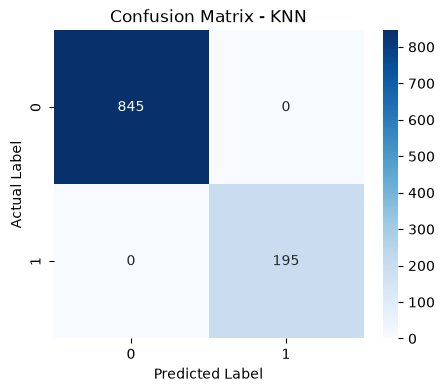

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - KNN")

plt.show()

## 10. Experiment with different values of K.


In [22]:
k_values = range(1,21)

accuracy_scores = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    score = accuracy_score(y_test,pred)

    accuracy_scores.append(score)

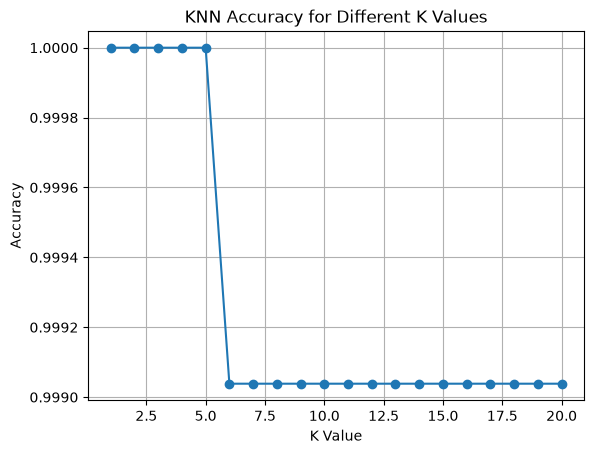

In [ ]:
plt.plot(k_values, accuracy_scores, marker='o')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.grid(True)
plt.show()

The graph shows how the value of K affects model accuracy. The best K is the one with the highest accuracy.

In [28]:
best_k = k_values[accuracy_scores.index(max(accuracy_scores))]

print("Best K:", best_k)

print("Best Accuracy:", max(accuracy_scores))

Best K: 1
Best Accuracy: 1.0


The optimal K value provides the highest classification accuracy on the testing dataset.

## 11. Analyze how distance metrics affect predictions.


In [29]:
metrics = ["euclidean","manhattan","minkowski"]

for metric in metrics:

    model = KNeighborsClassifier(
        n_neighbors=5,
        metric=metric
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    score = accuracy_score(y_test,pred)

    print(metric,"Accuracy:",round(score,4))

euclidean Accuracy: 1.0
manhattan Accuracy: 1.0
minkowski Accuracy: 1.0


Different distance metrics may produce different classification results because each calculates the distance between samples differently.

## 12. Identify cases where KNN misclassifies messages.

# Part D: Support Vector Machine Clssifier

## 13. Implement Support Vector Machine (SVM) classifier with:
    Linear kernel
    RBF or Polynomial kernel

## 14. Analyze margin separation and support vectors.


## 15. Compare SVM performance with KNN.


# Part E: Naive Bayes Classifier & Probability

## 16. Implement Naive Bayes Classifier.

## 17. Manually compute conditional probabilities for a few sample messages.


## 18. Demonstrate how Bayes’ Theorem is applied to compute class probabilities.


## 19. Compare theoretical probability calculations with model predictions.

# Part F: Model Comparison & Evaluation

## 20. Evaluate all models using appropriate classification metrics:
    ○ Accuracy
    ○ Precision
    ○ Recall
    ○ F1 Score

## 21. Compare:
    ● KNN vs SVM vs Naive Bayes

## 22. Identify which model performs best for:
    ● High precision
    ● High recall

# Part G: Final Analysis & Reporting